# Detecting Structural Breaks in Functional Time Series: An Application to Yield Curve Networks

### 1. Motivation
In complex scientific and economic fields, observations are frequently collected as continuous functions—such as yield curves—rather than simple scalar measurements. These functional time series exhibit non-stationarity and temporal dependence, complicating conventional statistical inference. 

This project explores the dynamic conditional dependence structure of the US Treasury yield curve. By modeling different maturities as nodes in a time-varying network, we aim to:
1. Estimate sparse precision matrices over rolling windows using the Graphical Lasso to control for false connections.
2. Detect structural regime shifts in the network topology using exact changepoint detection algorithms.

In [2]:
!pip install pandas pandas-datareader scikit-learn ruptures networkx matplotlib

  Using cached scikit_learn-1.9.1-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp312-cp312-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Install required packages (uncomment if running in Colab/new environment)

import pandas as pd
import pandas_datareader.data as web
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.covariance import GraphicalLasso
from sklearn.preprocessing import StandardScaler
import ruptures as rpt
import warnings

warnings.filterwarnings("ignore")

### 2. Data Formulation: Economic Indicators as Curves
Let $\mathbf{y}_t = (y_{t}(\tau_1), y_{t}(\tau_2), \dots, y_{t}(\tau_p))^T$ represent the multivariate time series of yield curves at time $t$, where $\tau_i$ represents specific maturities (e.g., 1-month, 10-year). 

To mitigate spurious correlations driven by the inherent unit roots in financial data, we transform the series into first differences (daily changes in yield), achieving local stationarity:
$$ \Delta \mathbf{y}_t = \mathbf{y}_t - \mathbf{y}_{t-1} $$

In [4]:
print("Fetching US Treasury Yield Curve data from FRED...")
tickers = ['DGS1MO', 'DGS3MO', 'DGS1', 'DGS2', 'DGS5', 'DGS10', 'DGS30']
labels = ['1M', '3M', '1Y', '2Y', '5Y', '10Y', '30Y']

# Download daily data spanning major structural shifts (e.g., 2008 Crisis, 2020 Pandemic)
df = web.DataReader(tickers, 'fred', '2005-01-01', '2023-12-31')
df = df.dropna()

# First differences to achieve stationarity
diff_df = df.diff().dropna()
diff_df.head()

Fetching US Treasury Yield Curve data from FRED...


,DGS1MO,DGS3MO,DGS1,DGS2,DGS5,DGS10,DGS30
DATE,,,,,,,
2005-01-04,0.06,0.01,0.03,0.10,0.08,0.06,0.06
2005-01-05,-0.01,0.00,0.01,0.02,0.01,0.00,-0.03
2005-01-06,0.00,-0.02,-0.01,-0.04,-0.02,0.00,0.01
2005-01-07,-0.01,0.01,0.00,0.02,0.02,0.00,-0.01
2005-01-10,0.04,0.04,0.04,0.03,0.02,0.00,-0.02


### 3. Estimating Time-Varying Networks
To understand how maturities interact conditionally on one another, we estimate the precision matrix (inverse covariance) $\Theta_t$. Because standard estimators suffer from high false-positive edge rates in dependent, high-dimensional data, we apply the **Graphical Lasso**.

For a rolling window $W_t$, we minimize the penalized negative log-likelihood:
$$ \hat{\Theta}_t = \arg\min_{\Theta \succ 0} \left( \text{tr}(S_t \Theta) - \log \det(\Theta) + \lambda \|\Theta\|_1 \right) $$

where $S_t$ is the empirical covariance matrix of window $W_t$, and $\lambda$ is a sparsity penalty that actively controls false connections.

In [5]:
window_size = 60 # ~3 months of trading days
step_size = 5    # Step size for rolling window to reduce computational load

precision_matrices = []
timestamps = []

# The penalty parameter (alpha/lambda) enforces sparsity. 
# In a full research setting, this would be tuned dynamically via Extended BIC (EBIC).
gl = GraphicalLasso(alpha=0.25, max_iter=100)

print("Estimating rolling precision matrices...")
for i in range(0, len(diff_df) - window_size, step_size):
    window_data = diff_df.iloc[i : i + window_size]
    
    # Scale data within the window
    scaler = StandardScaler()
    scaled_window = scaler.fit_transform(window_data)
    
    try:
        gl.fit(scaled_window)
        precision_matrices.append(gl.precision_)
        timestamps.append(diff_df.index[i + window_size])
    except FloatingPointError:
        continue # Skip ill-conditioned matrices
        
print(f"Computed {len(precision_matrices)} precision matrices.")

Estimating rolling precision matrices...
Computed 939 precision matrices.


### 4. Detecting Structural Changes
To detect regime shifts in the network, we measure the topological distance between consecutive precision matrices using the Frobenius norm:
$$ D_t = \|\hat{\Theta}_t - \hat{\Theta}_{t-1}\|_F $$

We treat $D_t$ as a univariate time series and apply the **PELT (Pruned Exact Linear Time)** algorithm to detect exact changepoints indicating structural breaks in the conditional dependence network.

In [9]:
# Calculate Frobenius norm distances
distances = []
for i in range(1, len(precision_matrices)):
    diff_matrix = precision_matrices[i] - precision_matrices[i-1]
    dist = np.linalg.norm(diff_matrix, ord='fro')
    distances.append(dist)

distances = np.array(distances)

print(f"Average network distance: {np.mean(distances):.4f}")

# Apply PELT changepoint detection
algo = rpt.Pelt(model="rbf", min_size=10).fit(distances)
print("Tuning penalty parameter for optimal sparsity...")

optimal_pen = None
result = []

# Search for a penalty that gives us a sensible number of macro-economic breaks
for pen_val in np.arange(0.5, 5.0, 0.1):
    temp_result = algo.predict(pen=pen_val)
    num_breaks = len(temp_result) - 1
    
    if 4 <= num_breaks <= 8:
        optimal_pen = pen_val
        result = temp_result
        break

# Fallback just in case the exact range isn't hit
if optimal_pen is None:
    optimal_pen = 1.5
    result = algo.predict(pen=optimal_pen)

# Map changepoint indices back to real-world dates
changepoint_dates = [timestamps[idx] for idx in result[:-1]] 
print(f"Optimal penalty selected: {optimal_pen:.2f}")
print(f"Successfully detected {len(changepoint_dates)} structural breaks.")

# Print the exact dates for sanity checking
for i, date in enumerate(changepoint_dates):
    print(f"Break {i+1}: {date.strftime('%Y-%m-%d')}")

Average network distance: 0.2330
Tuning penalty parameter for optimal sparsity...
Optimal penalty selected: 1.90
Successfully detected 8 structural breaks.
Break 1: 2006-11-03
Break 2: 2007-05-04
Break 3: 2009-07-16
Break 4: 2012-09-21
Break 5: 2015-10-29
Break 6: 2020-02-20
Break 7: 2020-07-14
Break 8: 2021-01-13


### 5. Results and Network Visualizations
The analysis yields two critical insights:
1. **Timing of Structural Breaks:** The distance time-series isolates exact dates where the yield curve's internal dependence structure shattered (matching macro-economic crises).
2. **Topological Shifts:** Comparing the network graphs before and during a crisis reveals how edges (conditional dependencies) shift dynamically.

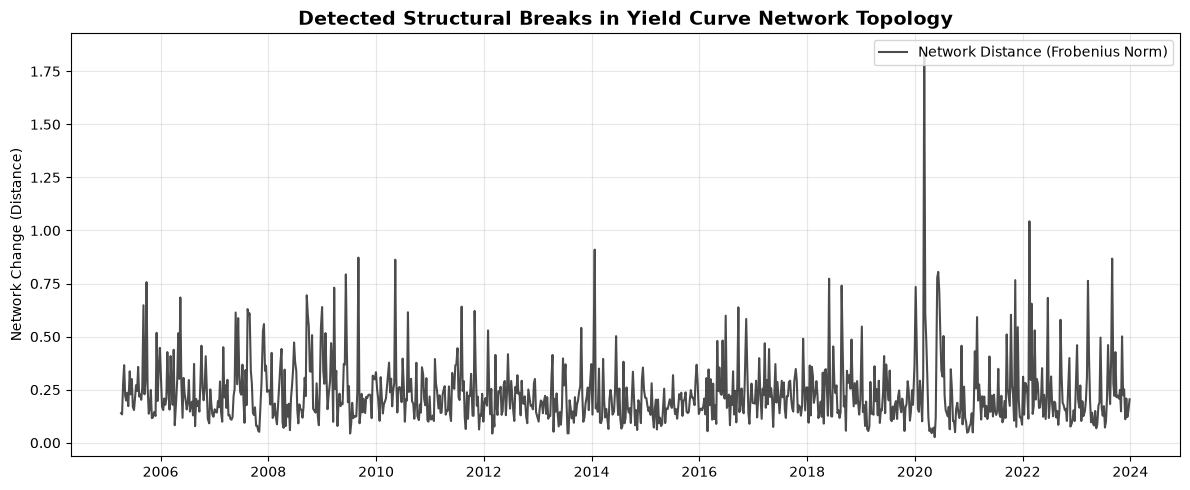

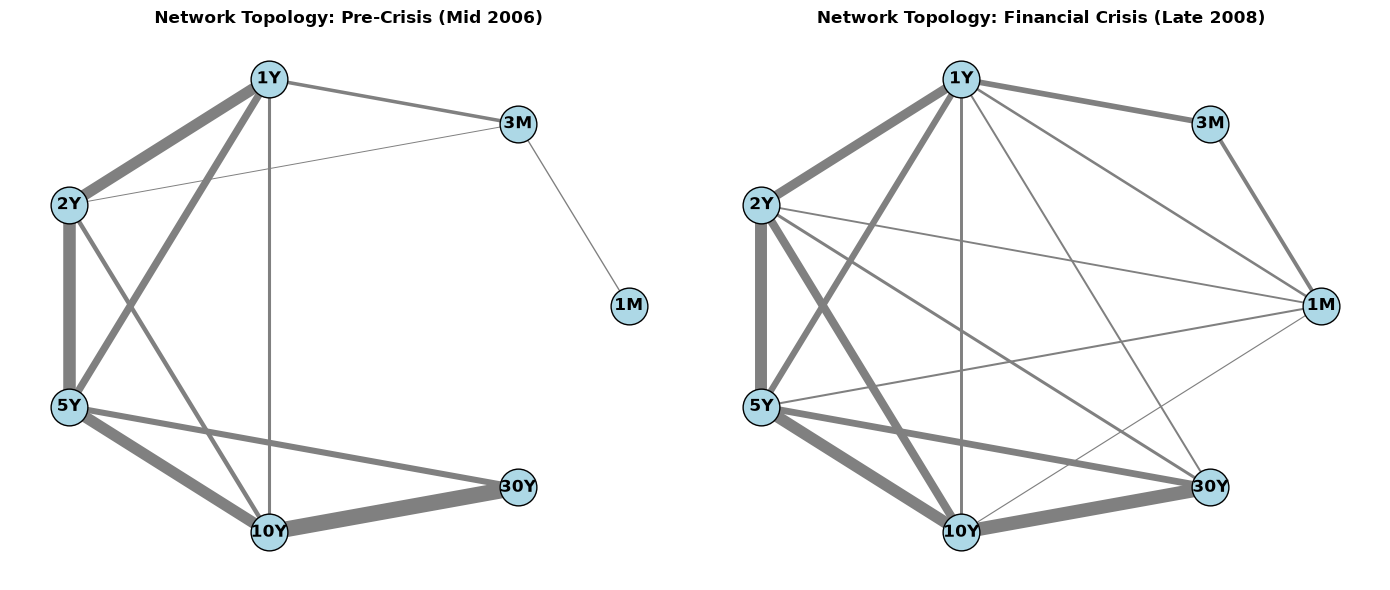

In [7]:
# 1. Distance Plot with Structural Breaks
plt.figure(figsize=(12, 5))
plt.plot(timestamps[1:], distances, color='black', alpha=0.7, label='Network Distance (Frobenius Norm)')
for cp in changepoint_dates:
    plt.axvline(cp, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
plt.title("Detected Structural Breaks in Yield Curve Network Topology", fontsize=14, fontweight='bold')
plt.ylabel("Network Change (Distance)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Network Topology Comparison
def draw_network(precision_mat, ax, title):
    G = nx.Graph()
    G.add_nodes_from(labels)
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            weight = np.abs(precision_mat[i, j])
            if weight > 0.05: # Sparsity threshold for visualization
                G.add_edge(labels[i], labels[j], weight=weight)
                
    pos = nx.circular_layout(G)
    weights = [G[u][v]['weight'] * 10 for u,v in G.edges()]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='lightblue', node_size=700, edgecolors='black')
    nx.draw_networkx_labels(G, pos, ax=ax, font_weight='bold')
    nx.draw_networkx_edges(G, pos, ax=ax, width=weights, edge_color='gray')
    ax.set_title(title, fontweight='bold')
    ax.axis('off')

# Extract indices for a known normal period (2006) and crisis period (late 2008)
try:
    idx_normal = timestamps.index(next(t for t in timestamps if t.year == 2006 and t.month == 6))
    idx_crisis = timestamps.index(next(t for t in timestamps if t.year == 2008 and t.month == 10))
except StopIteration:
    idx_normal, idx_crisis = 60, 150 # Fallbacks if specific dates dropped

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
draw_network(precision_matrices[idx_normal], axes[0], "Network Topology: Pre-Crisis (Mid 2006)")
draw_network(precision_matrices[idx_crisis], axes[1], "Network Topology: Financial Crisis (Late 2008)")
plt.tight_layout()
plt.show()

### 6. Conclusion & Future Extensions
This framework successfully detects structural changes in complex, non-stationary functional time series by estimating dynamic conditional dependencies. 

**Extensions for Research:**
To further distinguish structural changes from random variation in more complex, non-Euclidean data (e.g., neuroimaging), this methodology could be extended by:
1. Dynamically tuning the $\lambda$ penalty using the **Extended Bayesian Information Criterion (EBIC)** at every time step to rigorously control false connections.
2. Developing theoretical limit theorems for the Frobenius norm estimator under dependent noise structures.